# AI-Driven Student Performance Prediction System

## Objective:
To predict student performance using Machine Learning based on academic and behavioral factors.

In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd

df = pd.read_csv("../Dataset/student_data.csv")
df.head()


,gender,study_hours,attendance,previous_score,assignments_completed,sleep_hours,internet_access,extracurricular,final_score
0,Male,5,85,78,9,7,Yes,Yes,82
1,Female,6,90,85,10,8,Yes,Yes,90
2,Male,2,60,55,5,6,No,No,58
3,Female,8,95,92,10,7,Yes,Yes,96
4,Male,4,75,70,8,6,Yes,No,74


In [3]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   gender                 10 non-null     str  
 1   study_hours            10 non-null     int64
 2   attendance             10 non-null     int64
 3   previous_score         10 non-null     int64
 4   assignments_completed  10 non-null     int64
 5   sleep_hours            10 non-null     int64
 6   internet_access        10 non-null     str  
 7   extracurricular        10 non-null     str  
 8   final_score            10 non-null     int64
dtypes: int64(6), str(3)
memory usage: 955.0 bytes


In [4]:
# Statistical Summary
df.describe()


,study_hours,attendance,previous_score,assignments_completed,sleep_hours,final_score
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,5.000000,78.600000,73.800000,7.90000,6.900000,77.700000
std,2.581989,15.875908,16.274042,2.18327,0.994429,16.499495
min,1.000000,50.000000,45.000000,4.00000,5.000000,48.000000
25%,3.250000,67.500000,62.500000,6.50000,6.250000,67.250000
50%,5.000000,82.500000,77.000000,8.50000,7.000000,80.500000
75%,6.750000,89.500000,84.250000,9.75000,7.750000,89.250000
max,9.000000,98.000000,95.000000,10.00000,8.000000,98.000000


In [5]:
# Missing Values
df.isnull().sum()

gender                   0
study_hours              0
attendance               0
previous_score           0
assignments_completed    0
sleep_hours              0
internet_access          0
extracurricular          0
final_score              0
dtype: int64

In [6]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   gender                 10 non-null     str  
 1   study_hours            10 non-null     int64
 2   attendance             10 non-null     int64
 3   previous_score         10 non-null     int64
 4   assignments_completed  10 non-null     int64
 5   sleep_hours            10 non-null     int64
 6   internet_access        10 non-null     str  
 7   extracurricular        10 non-null     str  
 8   final_score            10 non-null     int64
dtypes: int64(6), str(3)
memory usage: 955.0 bytes


In [7]:
# Statistical Summary
df.describe()

,study_hours,attendance,previous_score,assignments_completed,sleep_hours,final_score
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,5.000000,78.600000,73.800000,7.90000,6.900000,77.700000
std,2.581989,15.875908,16.274042,2.18327,0.994429,16.499495
min,1.000000,50.000000,45.000000,4.00000,5.000000,48.000000
25%,3.250000,67.500000,62.500000,6.50000,6.250000,67.250000
50%,5.000000,82.500000,77.000000,8.50000,7.000000,80.500000
75%,6.750000,89.500000,84.250000,9.75000,7.750000,89.250000
max,9.000000,98.000000,95.000000,10.00000,8.000000,98.000000


In [8]:
# Check Missing Values
df.isnull().sum()

gender                   0
study_hours              0
attendance               0
previous_score           0
assignments_completed    0
sleep_hours              0
internet_access          0
extracurricular          0
final_score              0
dtype: int64

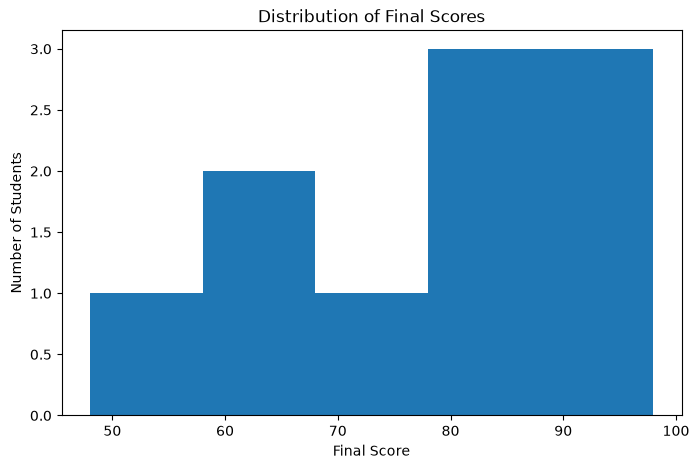

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["final_score"], bins=5)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

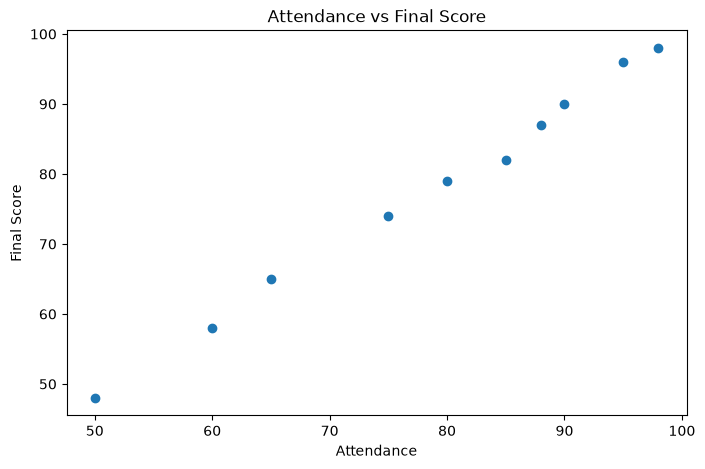

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df["attendance"], df["final_score"])

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance")
plt.ylabel("Final Score")

plt.show()

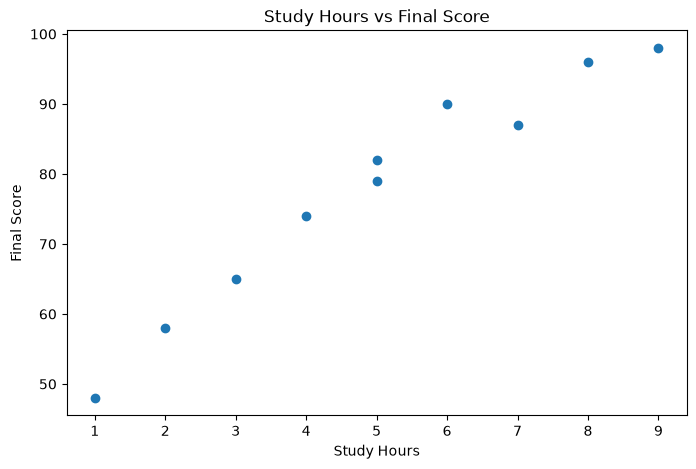

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(df["study_hours"], df["final_score"])

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

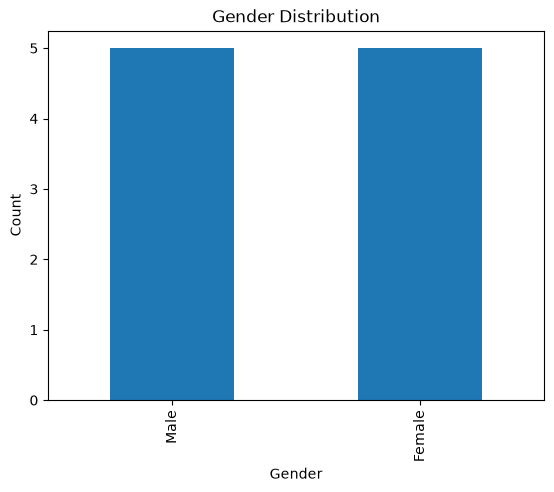

In [12]:
df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["internet_access"] = le.fit_transform(df["internet_access"])
df["extracurricular"] = le.fit_transform(df["extracurricular"])

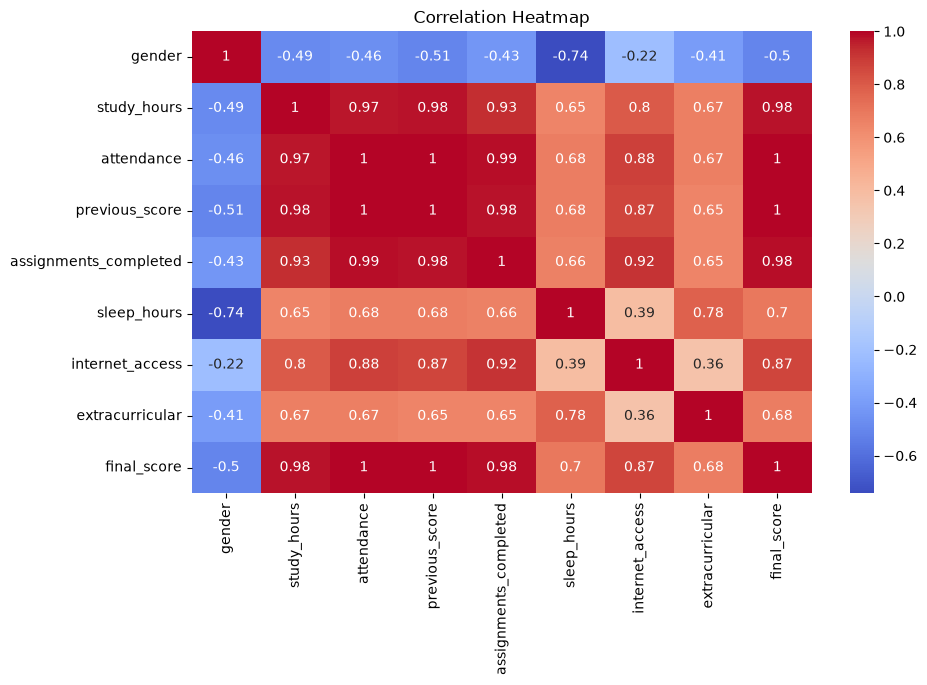

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [15]:
# Features and Target

X = df.drop("final_score", axis=1)
y = df["final_score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10, 8)
Target Shape: (10,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 8)
Testing Data: (2, 8)


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[61.93 87.79]


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))

R2 Score : 0.7744569160997733
MAE : 8.069999999999997
